# 3D example
This notebook shows a simple analysis pipeline for running and analyzing a 3D simulation with DISCO-DJ.

### Imports

In [2]:
# Import modules
import os
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from jax import config
import numpy as np
os.environ["USE_MASSIVE_NEUTRINOS"] = "0" #Def we use normal DISCO-DJ or Massive neutrinos version
from discodj import DiscoDJ
from discodj.disco_dj import DiscoDJ, DiscoDJnu
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)

0.7.2


In [3]:
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95" # maximize available memory (might need to tune this in case you're running out of memory)

### Simulation settings
DISCO-DJ can be run on a GPU (*much* faster) or on a CPU. The following cell detects if a GPU is available and sets the device accordingly.

In [4]:
# Detect if a GPU is available
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
print(device)

gpu


Now, we set the name of the analysis and the spatial dimension. The precision can be set to "single" (float32) or "double" (float64; in that case, the Jax config needs to be updated). DISCO-DJ is written in an class-based (yet functional) way, so you need to define a DiscoDJ object that will be used to perform all computations.

In [5]:
# Set the parameters
name = "3D_analysis"
dim = 3

precision = "single"
if precision == "double":
    config.update("jax_enable_x64", True)

# The cosmology can be provided as a dictionary or a string for a pre-defined cosmology (e.g. "CamelsCV" for the Camels Cosmic Variance suite).
# cosmo = "CamelsCV"
cosmo = dict(Omega_c=0.259605,  # cold dark matter content
             Omega_b=0.0488911,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
             h=0.67742,  # dimensionless Hubble constant
             n_s=0.96822,  # scalar spectral index
             sigma8=0.808992,
             mnu = 0.0  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
             )

cosmo_nu = dict(Omega_c=0.259605,  # cold dark matter content
             Omega_b=0.0488911,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
             h=0.67742,  # dimensionless Hubble constant
             n_s=0.96822,  # scalar spectral index
             sigma8=0.808992,  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
             mnu = 50)

# Define the boxsize and resolution
boxsize = 300.0  # in Mpc/h
res = 128  # the particles live on a Lagrangrian grid of resolution (res)^dim

In [6]:
# Define DISCO-DJ object
dj = DiscoDJnu(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)
dj_nu = DiscoDJnu(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo_nu)
print(dj)
print("##########3")
print(dj_nu)

DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 128³ particles
Boxsize: 300.0 Mpc/h
Precision: single
Device: gpu
Cosmology:
  Omega_c: 0.2596 
  Omega_b: 0.0489 
  Omega_de: 0.6914 
  h: 0.6774 
  n_s: 0.9682 
  sigma8: 0.8090 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 0.0000 
##########3
DiscoDJ
——————————
Name: 3D_analysis
Dimensions: 3D
Resolution: 128³ particles
Boxsize: 300.0 Mpc/h
Precision: single
Device: gpu
Cosmology:
  Omega_c: 0.2596 
  Omega_b: 0.0489 
  Omega_de: -0.4659 
  h: 0.6774 
  n_s: 0.9682 
  sigma8: 0.8090 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 50.0000 


Next, we compute the timetable for the cosmological growth functions.

In [7]:
# Compute the linear power spectrum
dj = dj.with_timetables()
dj_nu = dj_nu.with_timetables()

dj = dj.with_linear_ps(transfer_function="Eisenstein-Hu")
dj_nu = dj_nu.with_linear_ps(transfer_function="Eisenstein-Hu")

### Initial conditions

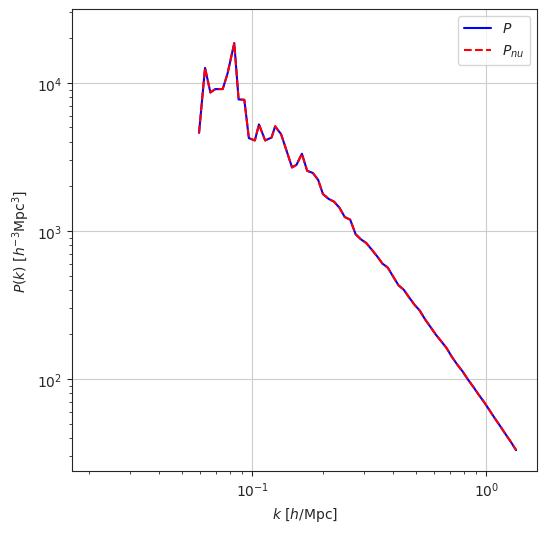

In [8]:
white_noise_field = dj.get_ngenic_noise(seed=24680)  # a white noise field, defined in real space

dj = dj.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)
dj_nu = dj_nu.with_ics(white_noise_space="real", white_noise_field=white_noise_field, convert_to_numpy=True)

#We can also compute the power spectrum of the pre-initial conditions:
k_pre, Pk_pre, _ = dj.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)
k_pre_nu, Pk_pre_nu, _ = dj_nu.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)
plt.figure(figsize=(6, 6))
plt.loglog(k_pre, Pk_pre, color='blue' , label=r'$P$')
plt.loglog(k_pre_nu, Pk_pre_nu , 'r--', label=r'$P_{nu}$')
plt.xlabel(r"$k$ [$h$/Mpc]")
plt.ylabel(r"$P(k)$ [$h^{-3}$Mpc$^3$]")
plt.legend()
plt.grid()
plt.show()

### Lagrangian perturbation theory (LPT)

In [9]:
n_order = 2
dj = dj.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability
dj_nu = dj_nu.with_lpt(n_order=n_order, convert_to_numpy=True)  # convert_to_numpy as above; note that this breaks differentiability

### Particle-mesh (PM) N-body simulation


In [10]:
# These options should be alright in many scenarios
stepper = "bullfrog"
method = "pm"
res_pm = 2 * dj.res
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 1
deconvolve = False
nlpt_order_ics = n_order
chunk_size = None  # if you are running out of GPU memory, doing the mass assignment in smaller chunks might help (e.g. chunk_size = dj.res ** dj.dim // 16)
numsteps = 10  # number of steps to be performed
a_ini = 0.02  # initial scale factor of the simulation (where it is initialized with LPT)
a_end = 1.0  # final scale factor of the simulation
a_list = np.linspace(a_ini, a_end, numsteps, endpoint=False)

In [11]:
X_sim, P_sim, a_sim = dj.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                   time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                   grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                   nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                   deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                   convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT


X_sim_nu, P_sim_nu, a_sim_nu = dj_nu.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                                   time_var=time_var, stepper=stepper, method=method, antialias=antialias,
                                   grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                   nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                   deconvolve=deconvolve, return_displacement=False, chunk_size=chunk_size,
                                   convert_to_numpy=True)  # convert_to_numpy: same as above for the ICs and LPT

### Analysis

Let's compute the power spectrum:

In [12]:
delta_sim = dj.get_delta_from_pos(X_sim, res=2 * dj.res, n_resample=8)
delta_sim_nu = dj_nu.get_delta_from_pos(X_sim_nu, res=2 * dj.res, n_resample=8)

#print(delta_sim)
#print("#####")
#print(delta_sim_nu)

In [13]:
k, Pk, _ = dj.evaluate_power_spectrum(delta_sim, bins=dj.res//3, deconvolve=True, worder=2)
k_nu, Pk_nu, _ = dj_nu.evaluate_power_spectrum(delta_sim_nu, bins=dj.res//3, deconvolve=True, worder=2)

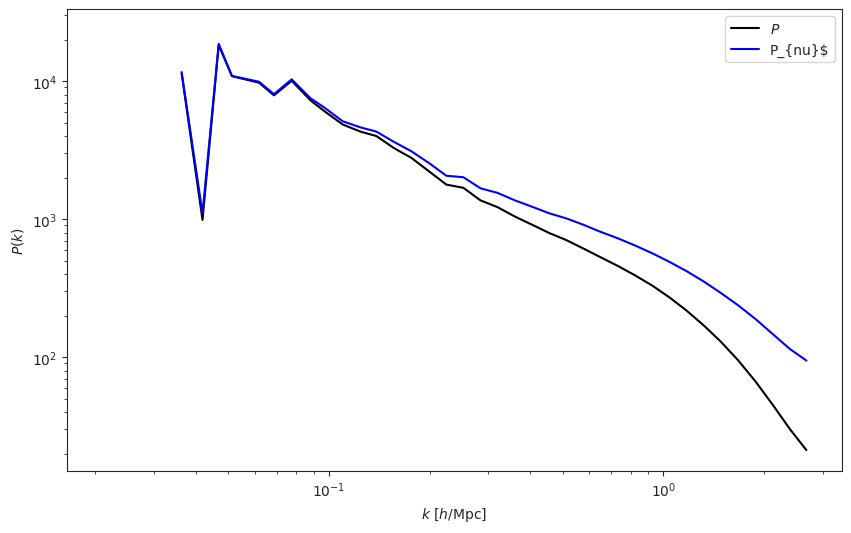

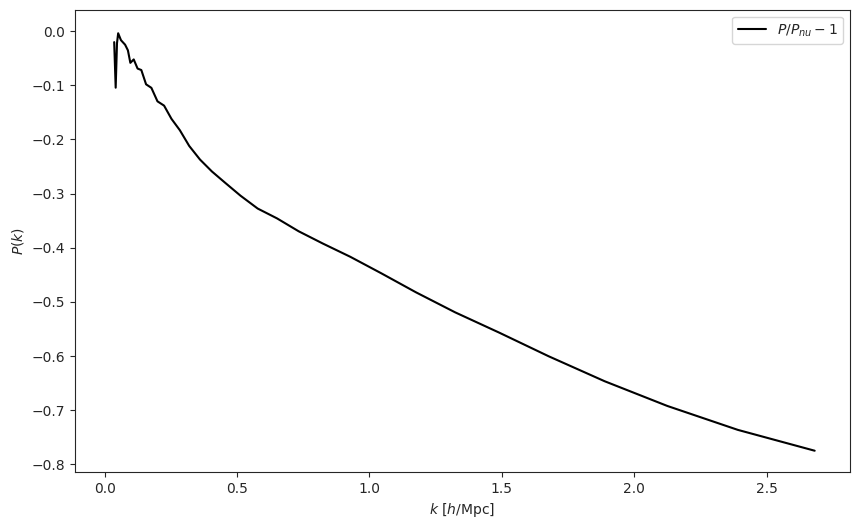

In [14]:
plt.figure(figsize=(10, 6))
plt.loglog(k, Pk, "k-", label="$P$")
plt.loglog(k, Pk_nu, "b-", label="P_{nu}$")
plt.xlabel(r"$k$ [$h$/Mpc]")
plt.ylabel(r"$P(k)$")
plt.legend(fontsize=10)

plt.figure(figsize=(10, 6))
plt.plot(k, Pk/Pk_nu -1, "k-", label="$P/P_{nu}-1$")
plt.xlabel(r"$k$ [$h$/Mpc]")
plt.ylabel(r"$P(k)$")
plt.legend(fontsize=10)

Text(0.5, 1.0, 'Massive')

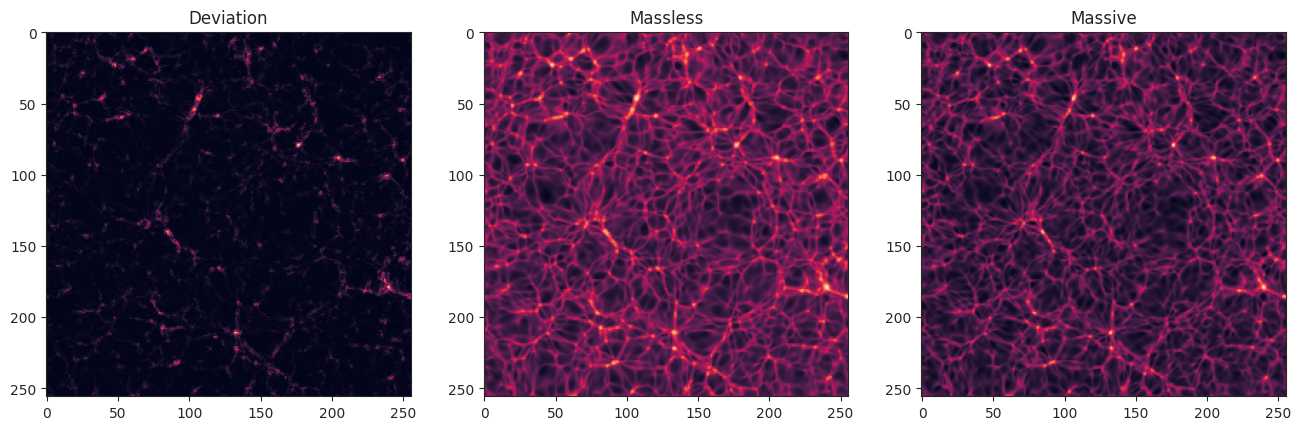

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(16, 8))
axs[0].imshow(np.log10(1.01 + np.abs(delta_sim[0, :, :] - delta_sim_nu[0, :, :]))); axs[0].set_title("Deviation")
axs[1].imshow(np.log10(1.01 + delta_sim[0, :, :])); axs[1].set_title("Massless")
axs[2].imshow(np.log10(1.01 + delta_sim_nu[0, :, :])); axs[2].set_title("Massive")